## Visuals For Report 


### Interpolation Bilinear downsampling

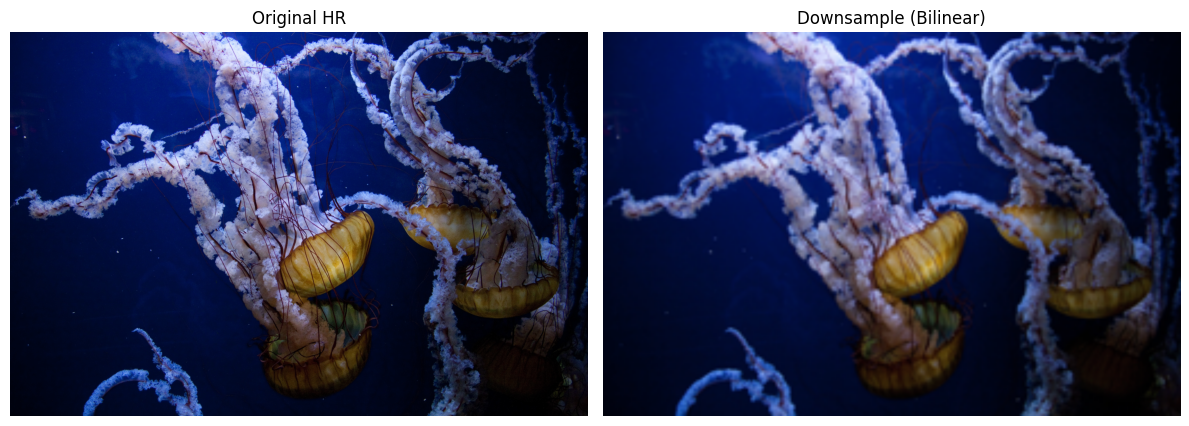

In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

img_path = Path("/Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Super_resolution/dataset/DIV2K_train_HR/0037.png")


hr = Image.open(img_path).convert("RGB")


scale = 8
lr = hr.resize((hr.width // scale, hr.height // scale), Image.BICUBIC)
bilinear = lr.resize(hr.size, Image.BILINEAR)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(hr); axes[0].set_title("Original HR"); axes[0].axis("off")
axes[1].imshow(bilinear); axes[1].set_title("Downsample (Bilinear)"); axes[1].axis("off")
plt.tight_layout()


### Super resolution 

[warn] load_model failed due to stale serialized graph; rebuilding the architecture and loading weights instead.


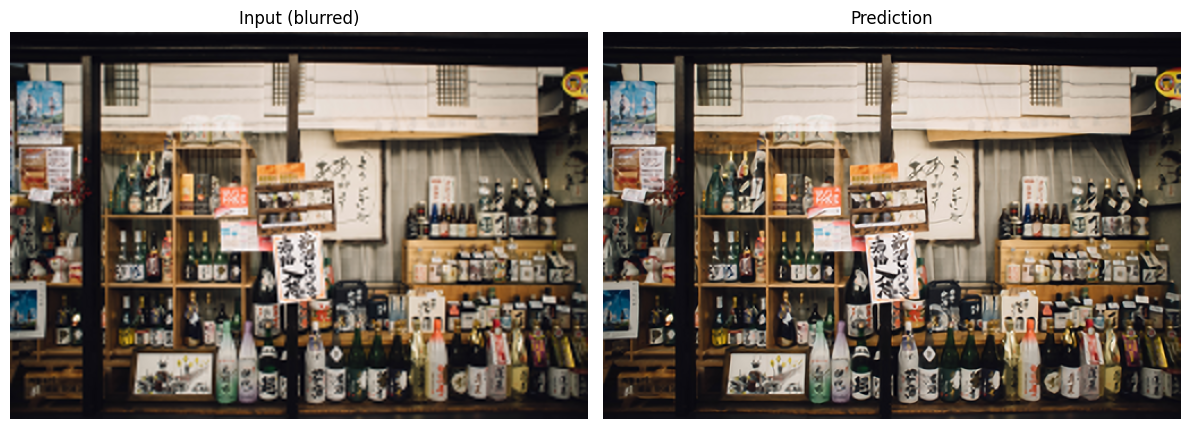

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Super_resolution")
# or Path.cwd() if you always run the notebook from that folder

for p in [PROJECT_ROOT, PROJECT_ROOT / "code", PROJECT_ROOT.parent]:
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

from shared.pipeline import load_rgb_image_full
from evaluate_model import load_checkpoint_model


MODEL_PATH = PROJECT_ROOT / "models/Experiment_2/exp2_adaptive_depth_scale0.80_20251107-143304/unet_adaptive_scale_new_loss0.80_depth5.keras"
IMG_PATH = PROJECT_ROOT / "dataset/DIV2K_train_LR_bicubic-2/X4/0018x4.png"

# Ensure imports work (if not already on sys.path)
for p in [PROJECT_ROOT, PROJECT_ROOT / "code"]:
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

# Config
patch_size = 256
stride = 256          # reduce (e.g., 192) for overlap/blending
down_factor = 0.5     # smaller -> blurrier input; set to 1.0 to skip blur

model = load_checkpoint_model(
    model_path=MODEL_PATH,
    scale=0.80,
    patch_size=patch_size,
    depth_override=5,
)

def pad_to_multiple(img, size):
    h, w, _ = img.shape
    pad_h = (-h) % size
    pad_w = (-w) % size
    if pad_h or pad_w:
        img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    return img, h, w

def extract_patches(img, size, stride):
    coords, patches = [], []
    h, w, _ = img.shape
    for y in range(0, h - size + 1, stride):
        for x in range(0, w - size + 1, stride):
            coords.append((y, x))
            patches.append(img[y:y+size, x:x+size, :])
    return np.stack(patches, 0), coords

def stitch(patches, coords, orig_h, orig_w, size, stride):
    h = coords[-1][0] + size
    w = coords[-1][1] + size
    acc = np.zeros((h, w, 3), dtype=np.float32)
    weight = np.zeros((h, w, 3), dtype=np.float32)
    for patch, (y, x) in zip(patches, coords):
        acc[y:y+size, x:x+size] += patch
        weight[y:y+size, x:x+size] += 1.0
    out = acc / np.maximum(weight, 1e-6)
    return out[:orig_h, :orig_w]

# Load input and optionally blur it
img = load_rgb_image_full(IMG_PATH)  # float32 0–1
orig_h, orig_w = img.shape[:2]
if down_factor != 1.0:
    low_h, low_w = max(1, int(orig_h * down_factor)), max(1, int(orig_w * down_factor))
    img = tf.image.resize(img, (low_h, low_w), method="bicubic").numpy()
    img = tf.image.resize(img, (orig_h, orig_w), method="bicubic").numpy()
img = np.clip(img, 0.0, 1.0)

# Pad, tile, run model
img_padded, orig_h, orig_w = pad_to_multiple(img, patch_size)
patches, coords = extract_patches(img_padded, patch_size, stride)

batch_size = 4
preds = []
for i in range(0, len(patches), batch_size):
    batch = patches[i:i+batch_size]
    pred1 = model(batch, training=False).numpy()
    pred2 = model(batch, training=False).numpy()
    preds2.append(np.clip(pred2, 0.0, 1.0))
preds = np.concatenate(preds, axis=0)

# Stitch and display
out_img = stitch(preds, coords, orig_h, orig_w, patch_size, stride)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img);     axes[0].set_title("Input (blurred)" if down_factor != 1.0 else "Input"); axes[0].axis("off")
axes[1].imshow(out_img); axes[1].set_title("Prediction"); axes[1].axis("off")
plt.tight_layout(); plt.show()


In [23]:
import numpy as np
import tensorflow as tf

pred = np.clip(out_img, 0, 1)
true = np.clip(img, 0, 1)

psnr = tf.image.psnr(true, pred, max_val=1.0).numpy().mean()
ssim = tf.image.ssim(true, pred, max_val=1.0).numpy().mean()
max_diff = np.abs(pred - true).max()
mean_diff = np.abs(pred - true).mean()
print(f"PSNR: {psnr:.2f} dB  SSIM: {ssim:.4f}  max diff: {max_diff:.3f}  mean diff: {mean_diff:.4f}")


PSNR: 31.72 dB  SSIM: 0.9720  max diff: 0.305  mean diff: 0.0135


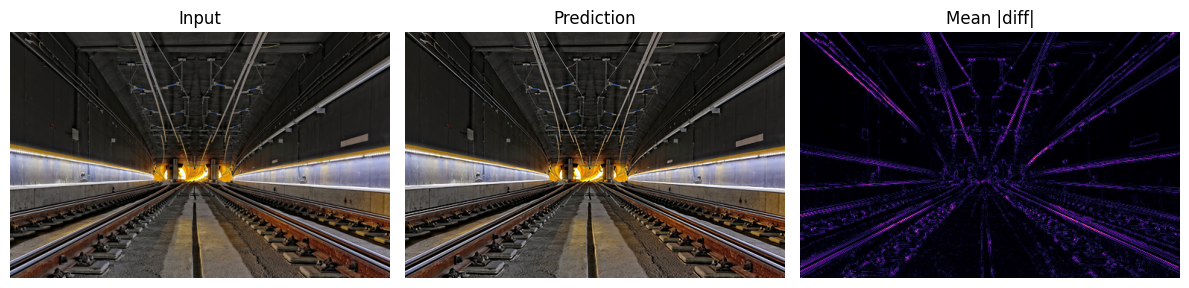

In [24]:
diff = np.abs(pred - true).mean(axis=2)  # per-pixel mean abs diff
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(true); plt.title("Input"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(pred); plt.title("Prediction"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(diff, cmap="magma"); plt.title("Mean |diff|"); plt.axis("off")
plt.tight_layout(); plt.show()


# Segmenetation 


2025-11-22 18:02:17.528616: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


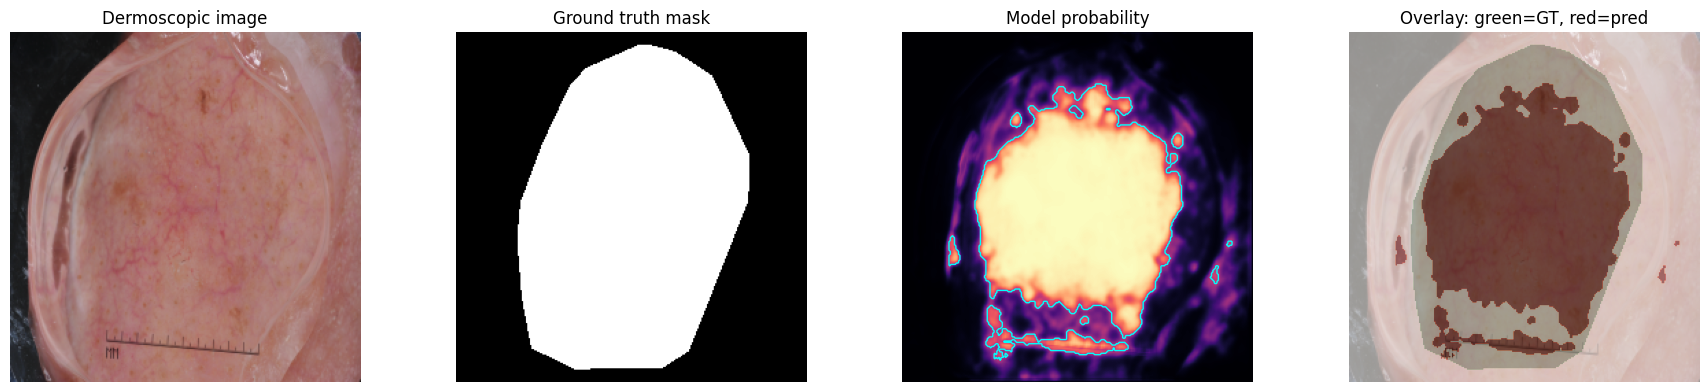

In [2]:
from pathlib import Path
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025")
sys.path.append(str(PROJECT_ROOT / "Segmenation" / "code"))

from train_adaptive_unet import (
    DEFAULT_IMAGE_SIZE,
    dice_coefficient,
    dice_loss,
    dice_metric,
    iou_metric,
    load_isic_image,
    load_isic_mask,
    make_hybrid_ce_dice_loss,
    make_bce_dice_loss,
)

MODEL_PATH = PROJECT_ROOT / "Segmenation/experiments/experiment_1_constant_depth_4/runs/models/exp1_depth4_scale0.90_20251114-081752/exp1_depth4_scale0.90.keras"
SAMPLE_ID = "ISIC_0012086"  # change to try another test sample
IMAGE_PATH = PROJECT_ROOT / "Segmenation/data/ISIC-2017_Test_v2_Data" / f"{SAMPLE_ID}.jpg"
MASK_PATH = PROJECT_ROOT / "Segmenation/data/ISIC-2017_Test_v2_Part1_GroundTruth" / f"{SAMPLE_ID}_segmentation.png"

if not IMAGE_PATH.exists() or not MASK_PATH.exists():
    raise FileNotFoundError(f"Missing sample or mask for {SAMPLE_ID}")

image = load_isic_image(tf.constant(str(IMAGE_PATH)), DEFAULT_IMAGE_SIZE)
mask = load_isic_mask(tf.constant(str(MASK_PATH)), DEFAULT_IMAGE_SIZE)

custom_objs = {
    "dice": dice_metric,
    "iou": iou_metric,
    "dice_coefficient": dice_coefficient,
    "dice_loss": dice_loss,
    "hybrid_ce_dice": make_hybrid_ce_dice_loss(alpha=0.4, beta=0.6),
    "bce_dice": make_bce_dice_loss(bce_weight=0.5, dice_weight=1.0),
}

model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objs, compile=False)

prob_map = model.predict(tf.expand_dims(image, 0), verbose=0)[0, ..., 0]
pred_mask = (prob_map > 0.5).astype(np.float32)

img_np = image.numpy()
gt_mask = tf.squeeze(mask).numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_np); axes[0].set_title("Dermoscopic image"); axes[0].axis("off")
axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Ground truth mask"); axes[1].axis("off")
axes[2].imshow(prob_map, cmap="magma"); axes[2].contour(pred_mask, levels=[0.5], colors=["cyan"], linewidths=1)
axes[2].set_title("Model probability"); axes[2].axis("off")
axes[3].imshow(img_np); axes[3].imshow(gt_mask, cmap="Greens", alpha=0.35)
axes[3].imshow(pred_mask, cmap="Reds", alpha=0.35); axes[3].set_title("Overlay: green=GT, red=pred"); axes[3].axis("off")
plt.tight_layout(); plt.show()


In [3]:
def dice_score(gt, pred):
    gt = gt.astype(np.float32).ravel()
    pred = pred.astype(np.float32).ravel()
    return 2 * (gt * pred).sum() / (gt.sum() + pred.sum() + 1e-7)

def iou_score(gt, pred):
    gt = gt.astype(np.float32).ravel()
    pred = pred.astype(np.float32).ravel()
    inter = (gt * pred).sum()
    union = gt.sum() + pred.sum() - inter + 1e-7
    return inter / union

print("Dice:", dice_score(gt_mask, pred_mask))
print("IoU:", iou_score(gt_mask, pred_mask))


Dice: 0.7858369768879102
IoU: 0.647225258823718


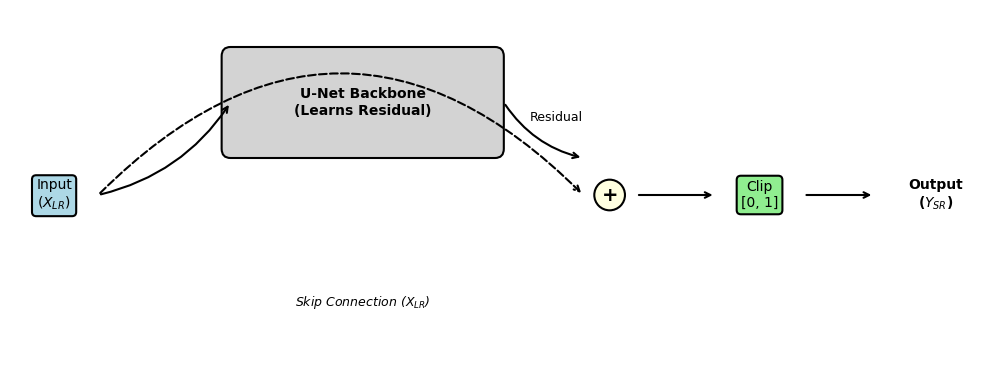

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_residual_head():
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 4)
    ax.axis('off')

    # Define styles
    box_props = dict(boxstyle="round,pad=0.3", fc="lightblue", ec="black", lw=1.5)
    op_props = dict(boxstyle="circle,pad=0.3", fc="lightyellow", ec="black", lw=1.5)
    clip_props = dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="black", lw=1.5)

    # 1. Input Node
    ax.text(0.5, 2, "Input\n($X_{LR}$)", ha="center", va="center", bbox=box_props, fontsize=10)

    # Bifurcation arrows
    # Arrow to U-Net (Upper path)
    ax.annotate("", xy=(2.5, 3), xytext=(1, 2),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", lw=1.5))

    # Arrow to Add (Lower path - Skip)
    ax.annotate("", xy=(6.5, 2), xytext=(1, 2),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.5", linestyle="--", lw=1.5))
    ax.text(4, 0.8, "Skip Connection ($X_{LR}$)", ha="center", fontsize=9, style='italic')

    # 2. U-Net Backbone (The Function F(x))
    unet_box = patches.FancyBboxPatch((2.5, 2.5), 3, 1, boxstyle="round,pad=0.1", fc="lightgrey", ec="black", lw=1.5)
    ax.add_patch(unet_box)
    ax.text(4, 3, "U-Net Backbone\n(Learns Residual)", ha="center", va="center", fontsize=10, fontweight='bold')

    # Arrow from U-Net to Add
    ax.annotate("", xy=(6.5, 2.4), xytext=(5.6, 3),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", lw=1.5))
    ax.text(6.2, 2.8, "Residual", ha="center", fontsize=9)

    # 3. Add Operation
    ax.text(6.8, 2, "+", ha="center", va="center", bbox=op_props, fontsize=14, fontweight='bold')

    # Arrow from Add to Clip
    ax.annotate("", xy=(8, 2), xytext=(7.1, 2), arrowprops=dict(arrowstyle="->", lw=1.5))

    # 4. Clip Operation
    ax.text(8.5, 2, "Clip\n[0, 1]", ha="center", va="center", bbox=clip_props, fontsize=10)

    # Arrow from Clip to Output
    ax.annotate("", xy=(9.8, 2), xytext=(9, 2), arrowprops=dict(arrowstyle="->", lw=1.5))

    # 5. Output Node
    ax.text(10.5, 2, "Output\n($Y_{SR}$)", ha="center", va="center", fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig("residual_head_diagram.png", dpi=300, bbox_inches='tight')
    plt.show()

draw_residual_head()